# Regression Tree

## Intuition

A Regression Tree partitions the feature space into rectangular regions using recursive binary splits, then predicts the mean target value within each region. The structure is identical to a Decision Tree Classifier, but the splitting criterion and leaf prediction differ: instead of Gini impurity, we minimize variance; instead of a majority class, we predict a mean.

Think of it as drawing a series of axis-aligned cuts through the feature space. After each cut, the model asks: "does this split reduce the variance of the target within each subgroup?" The split that gives the largest reduction is chosen at each node. The process repeats recursively until a depth limit or minimum leaf size is reached.

The resulting predictions are **piecewise constant**: within each leaf region, the model always predicts the same value (the mean of training targets in that leaf).

---

## Math

**Variance Reduction Criterion.** At each node with $N$ samples, consider all possible binary splits into left ($N_L$ samples) and right ($N_R$ samples) subsets. Choose the split that maximizes:

$$\text{Gain} = \text{Var}(y_{\text{parent}}) - \frac{N_L}{N} \text{Var}(y_{\text{left}}) - \frac{N_R}{N} \text{Var}(y_{\text{right}})$$

where $\text{Var}(y) = \frac{1}{|S|} \sum_{i \in S} (y_i - \bar{y})^2$ is the variance within set $S$.

**Leaf prediction.** Each leaf predicts the mean of training targets in that leaf:

$$\hat{y} = \frac{1}{|\text{leaf}|} \sum_{i \in \text{leaf}} y^{(i)}$$

**Equivalently**, the split criterion minimizes the weighted MSE of the split:

$$\text{MSE}_{\text{split}} = \frac{N_L}{N} \cdot \text{Var}(y_{\text{left}}) + \frac{N_R}{N} \cdot \text{Var}(y_{\text{right}})$$

---

## Algorithm Steps

1. Start at the root with all training samples.
2. For each node, search over all features $j$ and all split thresholds $t$:
   - Compute the variance reduction for the split $(j, t)$.
3. Apply the best split to create two child nodes.
4. Recurse on each child until a stopping condition is met (max depth, min samples per leaf, or zero variance gain).
5. At each leaf, store $\hat{y} = \text{mean}(y_{\text{leaf}})$.
6. To predict a new point: traverse the tree from root to a leaf by following split conditions; return the leaf mean.

---

## How Regression Tree Differs from Classification Tree

| Property | Classification Tree | Regression Tree |
|---|---|---|
| Target | Discrete class labels | Continuous values |
| Splitting criterion | Gini impurity or entropy | Variance reduction (MSE) |
| Leaf prediction | Majority class | Mean of target values |
| Output | Class label | Real-valued number |
| Evaluation metric | Accuracy, F1 | RMSE, $R^2$ |

---

## Advantages

- Can model **non-linear** relationships without feature engineering.
- Highly **interpretable**: the tree structure can be visualized and explained.
- Handles mixed feature types (continuous and categorical) natively.
- Robust to outliers in features (splits are threshold-based, not distance-based).
- No need to scale features.

## Disadvantages

- Predictions are **piecewise constant**: the model cannot extrapolate beyond the training range.
- Prone to **overfitting** if max_depth is not constrained.
- Unstable: small changes in the data can produce very different trees.
- Typically lower accuracy than ensemble methods (Random Forest, Gradient Boosting).

## Solutions to Disadvantages

- Use **Random Forests** to average many trees, reducing variance and overfitting.
- Use **Gradient Boosting** to sequentially correct residuals for higher accuracy.
- Apply **pruning** or **min_samples_leaf** constraints to prevent overfitting.
- Use **cross-validation** to select the optimal max_depth.

---

## Summary

| Property | Value |
|---|---|
| Type | Non-parametric regression |
| Splitting criterion | Variance reduction (MSE) |
| Leaf prediction | Mean of target values |
| Decision boundary | Axis-aligned rectangles |
| Requires scaling | No |
| Key hyperparameter | max_depth |
| Evaluation metric | RMSE, $R^2$ |

**Dataset:** Gym Members Exercise Tracking (`gym_members_exercise_tracking.csv`). 973 samples. Predict `Session_Duration (hours)` from age, weight, calories burned, and other features.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

from rice_ml.supervised_learning import DecisionTreeRegressor
from rice_ml.preprocess import StandardScaler, train_test_split
from rice_ml.metrics import mse, rmse, r2_score

In [2]:
try:
    df = pd.read_csv('../../../data/gym_members_exercise_tracking.csv')
    target_col = 'Session_Duration (hours)'
    feature_cols = ['Age', 'Weight (kg)', 'Calories_Burned', 'Workout_Frequency (days/week)', 'Fat_Percentage']
    df = df[feature_cols + [target_col]].dropna()
    X = df[feature_cols].values.astype(float)
    y = df[target_col].values.astype(float)
    print(f'Loaded gym dataset: {X.shape}')
except FileNotFoundError:
    from sklearn.datasets import make_regression
    X, y = make_regression(n_samples=300, n_features=5, noise=0.5, random_state=0)
    feature_cols = [f'Feature_{i}' for i in range(5)]
    target_col = 'Target'
    df = None
    print('CSV not found. using synthetic regression data')

print(f'Target range: [{y.min():.2f}, {y.max():.2f}]')

Loaded gym dataset: (973, 5)
Target range: [0.50, 2.00]


## Dataset Description

The **Gym Members Exercise Tracking** dataset (`gym_members_exercise_tracking.csv`) contains 973 gym members with information about their demographics, body composition, and workout patterns.

**Features used for this regression task:**

| Feature | Description |
|---|---|
| Age | Member age in years |
| Weight (kg) | Body weight in kilograms |
| Calories_Burned | Total calories burned in the session |
| Workout_Frequency (days/week) | How many days per week the member works out |
| Fat_Percentage | Body fat percentage |

**Target:** `Session_Duration (hours)`. The length of a workout session.

Session duration is influenced by multiple factors in a non-linear way. For example, the relationship between calories burned and session duration may differ depending on workout intensity and the member's weight. A regression tree can capture these interactions without assuming a global linear form.

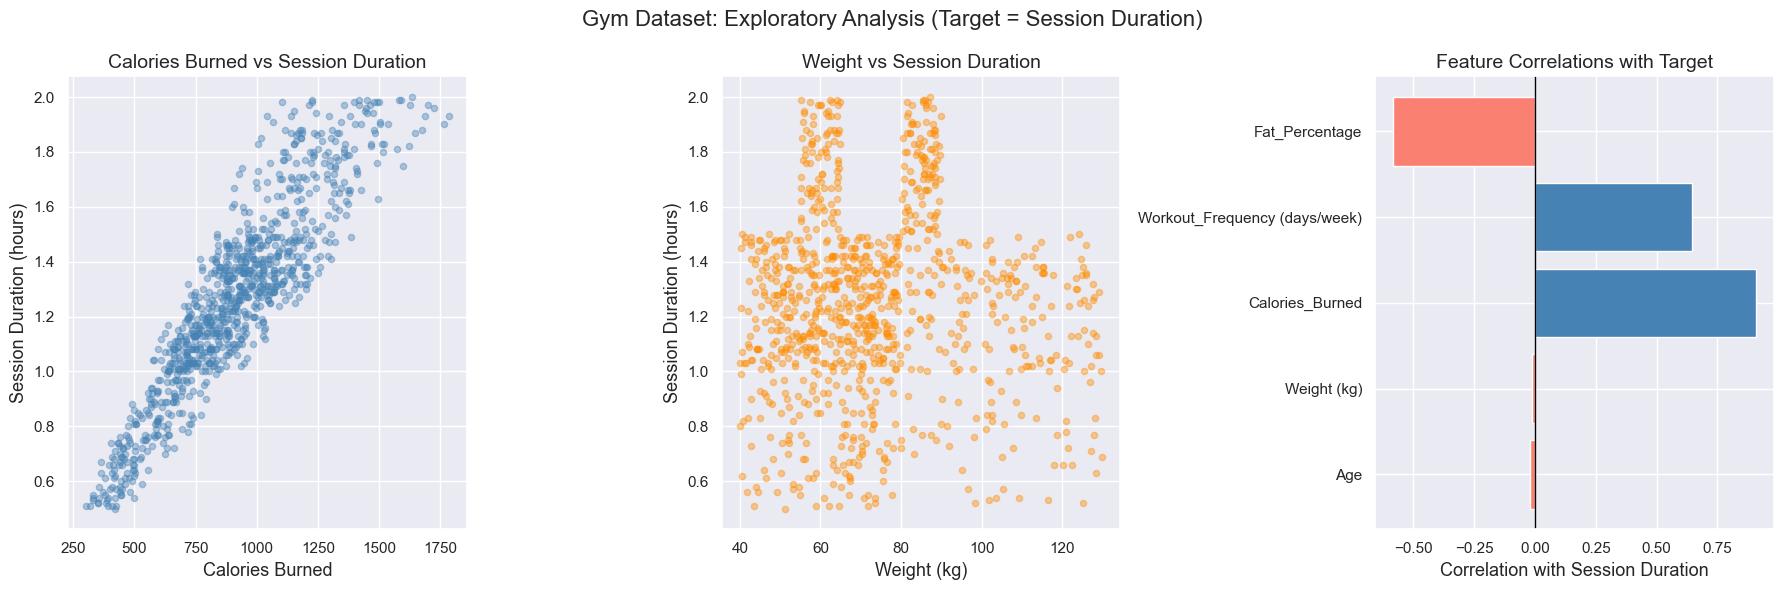

Feature correlations with Session Duration (hours):
  Calories_Burned                         : +0.908
  Workout_Frequency (days/week)           : +0.644
  Weight (kg)                             : -0.014
  Age                                     : -0.020
  Fat_Percentage                          : -0.582


In [3]:
# EDA: Scatter of Calories_Burned vs Session_Duration;
#      Scatter of Weight vs Session_Duration;
#      Correlation of features with target
if df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Calories_Burned vs Session_Duration
    axes[0].scatter(df['Calories_Burned'], df[target_col],
                    alpha=0.4, color='steelblue', s=20)
    axes[0].set_xlabel('Calories Burned', fontsize=13)
    axes[0].set_ylabel('Session Duration (hours)', fontsize=13)
    axes[0].set_title('Calories Burned vs Session Duration', fontsize=14)

    # Weight vs Session_Duration
    axes[1].scatter(df['Weight (kg)'], df[target_col],
                    alpha=0.4, color='darkorange', s=20)
    axes[1].set_xlabel('Weight (kg)', fontsize=13)
    axes[1].set_ylabel('Session Duration (hours)', fontsize=13)
    axes[1].set_title('Weight vs Session Duration', fontsize=14)

    # Correlation bar chart
    corr_vals = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
    colors_bar = ['salmon' if v < 0 else 'steelblue' for v in corr_vals.values]
    axes[2].barh(corr_vals.index, corr_vals.values, color=colors_bar, edgecolor='white')
    axes[2].axvline(0, color='black', lw=1)
    axes[2].set_xlabel('Correlation with Session Duration', fontsize=13)
    axes[2].set_title('Feature Correlations with Target', fontsize=14)

    plt.suptitle('Gym Dataset: Exploratory Analysis (Target = Session Duration)', fontsize=16)
    plt.tight_layout()
    plt.show()

    print('Feature correlations with Session Duration (hours):')
    for feat, val in corr_vals.sort_values(ascending=False).items():
        print(f'  {feat:40s}: {val:+.3f}')
else:
    print('EDA skipped: using fallback dataset.')

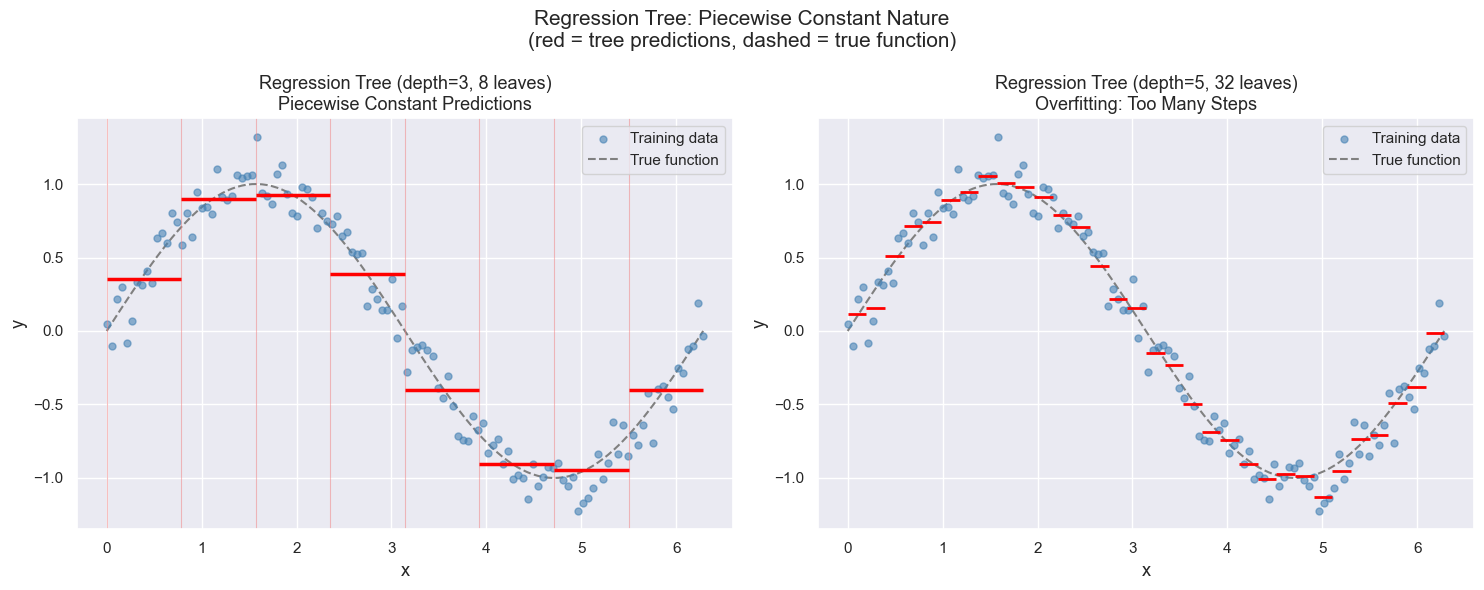

In [4]:
# Diagram: Piecewise constant predictions of a regression tree
# Shows noisy sine-wave data with a step-function tree approximation overlaid

rng = np.random.default_rng(42)
x_1d = np.linspace(0, 2 * np.pi, 120)
y_1d = np.sin(x_1d) + rng.normal(0, 0.15, 120)

# Fit a shallow sklearn-like piecewise constant approximation manually
# using a depth-3 partition (8 bins)
n_bins = 8
bin_edges = np.linspace(x_1d.min(), x_1d.max(), n_bins + 1)
bin_means = []
bin_centers = []
for i in range(n_bins):
    mask = (x_1d >= bin_edges[i]) & (x_1d < bin_edges[i + 1])
    if mask.sum() > 0:
        bin_means.append(y_1d[mask].mean())
        bin_centers.append((bin_edges[i], bin_edges[i + 1]))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: shallow tree (8 regions)
axes[0].scatter(x_1d, y_1d, color='steelblue', alpha=0.6, s=25, label='Training data', zorder=2)
axes[0].plot(x_1d, np.sin(x_1d), color='gray', lw=1.5, linestyle='--', label='True function', zorder=1)
for (lo, hi), mean_val in zip(bin_centers, bin_means):
    axes[0].hlines(mean_val, lo, hi, colors='red', lw=2.5, zorder=3)
    axes[0].axvline(lo, color='lightcoral', lw=0.8, alpha=0.5)
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('y', fontsize=13)
axes[0].set_title('Regression Tree (depth=3, 8 leaves)\nPiecewise Constant Predictions', fontsize=13)
axes[0].legend(fontsize=11)

# Right: deep tree (32 bins, nearly memorizes)
n_bins_deep = 32
bin_edges_deep = np.linspace(x_1d.min(), x_1d.max(), n_bins_deep + 1)
for i in range(n_bins_deep):
    mask = (x_1d >= bin_edges_deep[i]) & (x_1d < bin_edges_deep[i + 1])
    if mask.sum() > 0:
        mean_deep = y_1d[mask].mean()
        axes[1].hlines(mean_deep, bin_edges_deep[i], bin_edges_deep[i + 1],
                       colors='red', lw=2, zorder=3)

axes[1].scatter(x_1d, y_1d, color='steelblue', alpha=0.6, s=25, label='Training data', zorder=2)
axes[1].plot(x_1d, np.sin(x_1d), color='gray', lw=1.5, linestyle='--', label='True function', zorder=1)
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('Regression Tree (depth=5, 32 leaves)\nOverfitting: Too Many Steps', fontsize=13)
axes[1].legend(fontsize=11)

plt.suptitle('Regression Tree: Piecewise Constant Nature\n(red = tree predictions, dashed = true function)',
             fontsize=15)
plt.tight_layout()
plt.show()

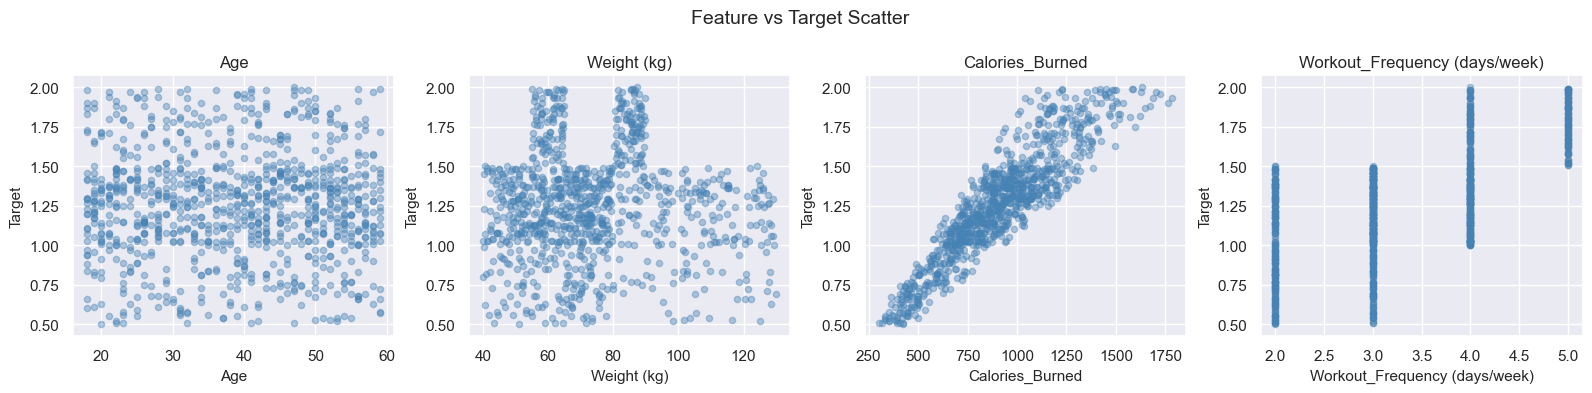

In [5]:
# EDA: scatter each feature vs target
try:
    feat_names = feature_cols
except NameError:
    feat_names = [f'Feature {i}' for i in range(X.shape[1])]

n_features = min(X.shape[1], 4)
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 4))
if n_features == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.scatter(X[:, i], y, alpha=0.4, color='steelblue', s=20)
    ax.set_xlabel(feat_names[i], fontsize=11)
    ax.set_ylabel('Target', fontsize=11)
    ax.set_title(feat_names[i], fontsize=12)
plt.suptitle('Feature vs Target Scatter', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Effect of `max_depth` on Regression Error

Shallow trees underfit (high bias), deep trees overfit (low training error but high test error).

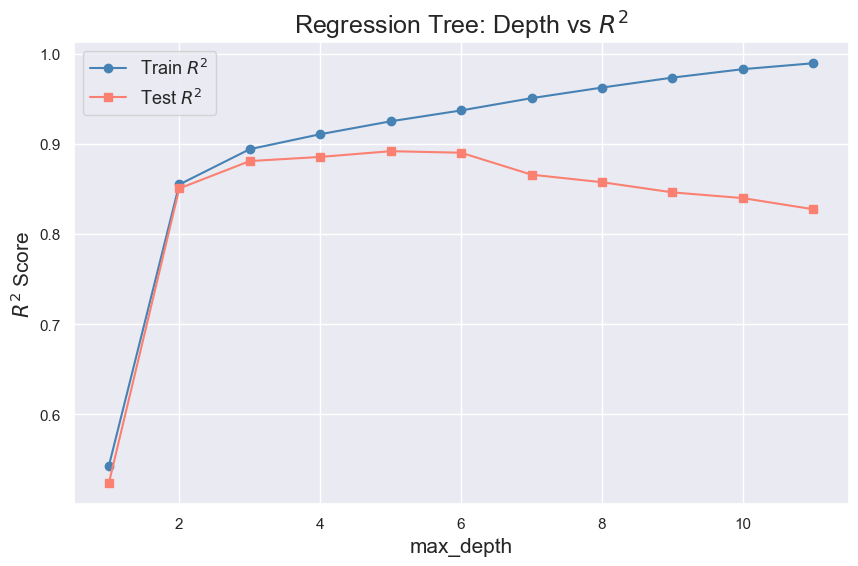

In [7]:
depths = range(1, 12)
train_r2, test_r2 = [], []

for d in depths:
    reg = DecisionTreeRegressor(max_depth=d)
    reg.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, reg.predict(X_train)))
    test_r2.append(r2_score(y_test, reg.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_r2, marker='o', label='Train $R^2$', color='steelblue')
plt.plot(depths, test_r2, marker='s', label='Test $R^2$', color='salmon')
plt.xlabel('max_depth', fontsize=15)
plt.ylabel('$R^2$ Score', fontsize=15)
plt.title('Regression Tree: Depth vs $R^2$', fontsize=18)
plt.legend(fontsize=13)
plt.show()

In [8]:
best_depth = list(depths)[np.argmax(test_r2)]
reg = DecisionTreeRegressor(max_depth=best_depth)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f'Best depth: {best_depth}')
print(f'Test MSE:  {mse(y_test, y_pred):.4f}')
print(f'Test RMSE: {rmse(y_test, y_pred):.4f}')
print(f'Test R\u00b2:   {r2_score(y_test, y_pred):.4f}')

Best depth: 5
Test MSE:  0.0144
Test RMSE: 0.1201
Test R²:   0.8921


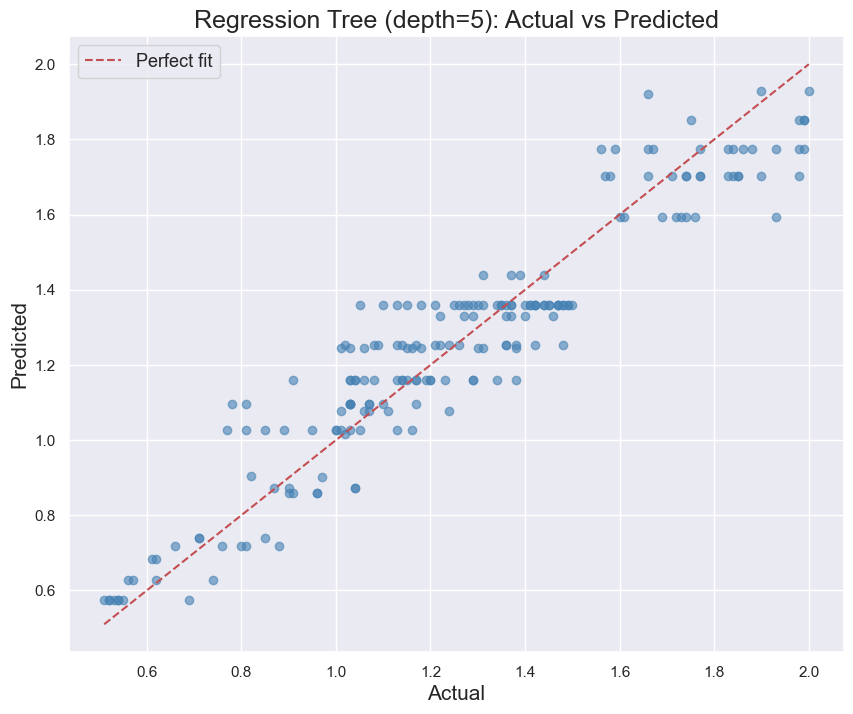

In [9]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect fit')
plt.xlabel('Actual', fontsize=15)
plt.ylabel('Predicted', fontsize=15)
plt.title(f'Regression Tree (depth={best_depth}): Actual vs Predicted', fontsize=18)
plt.legend(fontsize=13)
plt.show()

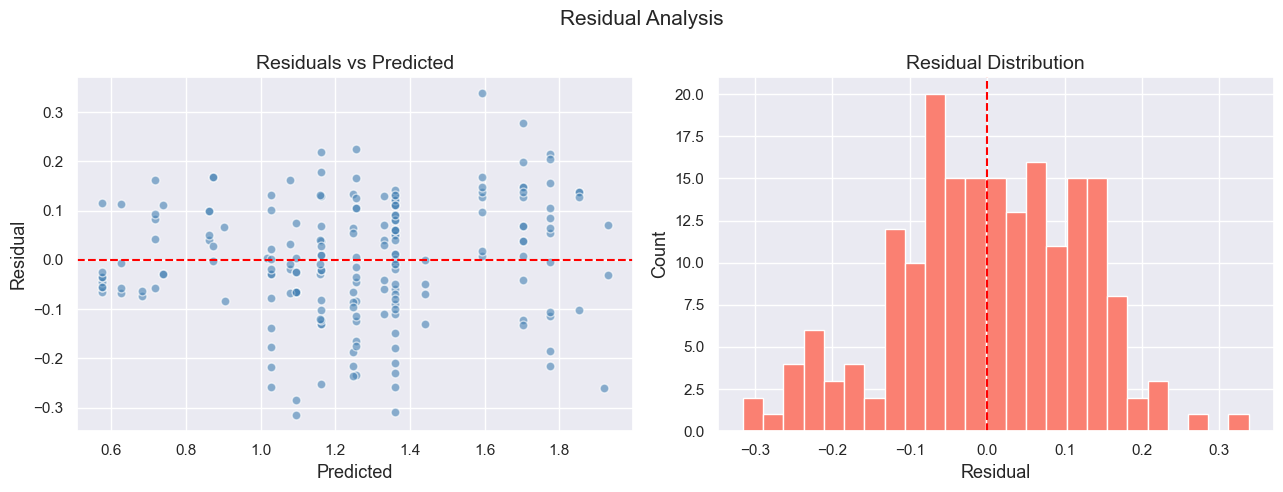

Mean residual:    0.0004  (should be near 0)
Std of residuals: 0.1201


In [10]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.6, color='steelblue', edgecolors='white', s=40)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted', fontsize=13)
axes[0].set_ylabel('Residual', fontsize=13)
axes[0].set_title('Residuals vs Predicted', fontsize=14)

axes[1].hist(residuals, bins=25, color='salmon', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Residual Distribution', fontsize=14)

plt.suptitle('Residual Analysis', fontsize=15)
plt.tight_layout()
plt.show()

print(f'Mean residual:    {residuals.mean():.4f}  (should be near 0)')
print(f'Std of residuals: {residuals.std():.4f}')

## Interpretation

**Piecewise constant nature:** The diagram shows the key characteristic of a regression tree: predictions are constant within each leaf region. With only 8 leaves (depth 3), the tree approximates the underlying curve coarsely. With 32 leaves (depth 5), it begins to fit the noise rather than the signal.

**Depth vs R-squared:** At depth 1 (a single split), the tree is severely underfitting. Training $R^2$ rises monotonically with depth, but test $R^2$ peaks and then declines as the tree overfits. The optimal depth balances bias and variance.

**Actual vs Predicted:** For regression trees, the predicted values cluster at discrete levels (the leaf means), so the actual vs predicted scatter shows horizontal bands. This is expected and confirms the piecewise constant nature of the model.

**Residual patterns:** The vertical striping in the residuals vs predicted plot (distinct columns of points) is another signature of piecewise constant predictions. Each column corresponds to one leaf. Linear regression residuals would show a smooth scatter instead.

**When to prefer a tree over linear regression:** If the Calories_Burned vs Session_Duration relationship is non-linear (e.g., a plateau at high calorie values), the regression tree will capture it naturally. Linear regression would require manually adding polynomial features. The EDA scatter plots reveal whether such non-linearity exists in this dataset.

**Next steps:** A Random Forest (ensemble of many trees with random feature subsampling) would reduce the variance and produce smoother, more accurate predictions without the discrete-level artifacts.